### Overview

This code takes different **urbanization scenarios**, provided in **pickle format** and generated by the previous code `wilcoxon_test_and_plot`, and creates various **graphs** to compare them.

The urbanization scenarios represent changes in imp %. For each scenario, it generates visualizations that compare the effects of different urbanization levels on runoff behavior.

The resulting plots offer a clear comparison between the different scenarios, helping to evaluate and understand how urbanization influences rainfall and discharge dynamics.


## Imports and files

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

In [2]:
sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion"
save_dir = r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts\combined_shifts'
os.makedirs(save_dir, exist_ok=True)

rain_shift_classes = [
    ('urbanization_1_0.pkl', 'urbanization_1_0', '39% urbanization'),
    ('urbanization_1_1.pkl', 'urbanization_1_1', '42% urbanization'),
    ('urbanization_1_2.pkl', 'urbanization_1_2', '46% urbanization'),
    ('urbanization_1_3.pkl', 'urbanization_1_3', '49% urbanization'),
    ('urbanization_1_4.pkl', 'urbanization_1_4', '53% urbanization'),
    ('urbanization_1_5.pkl', 'urbanization_1_5', '57% urbanization'),
    ('urbanization_2_0.pkl', 'urbanization_2_0', '73% urbanization'),
    ('urbanization_3_0.pkl', 'urbanization_3_0', '81% urbanization'),
    ('urbanization_5_0.pkl', 'urbanization_5_0', '87% urbanization')]


In [6]:
# Colors for historical and future data
historical_color = sns.color_palette("Set2")[0]
future_color = sns.color_palette("Set2")[1]

# Load data from pickle files
all_data = []
labels = []
for file_name, pickle_file, label_name in rain_shift_classes:
    print(label_name)
    pickle_file_path = os.path.join(sim_dir, f'all_events_direc_{pickle_file}.pkl')
    if os.path.exists(pickle_file_path):
        
        all_events_direc_df = pd.read_pickle(pickle_file_path)
#         print(all_events_direc_df.index)
        all_events_direc_df = all_events_direc_df.xs('Most_Urban_S27', level=0)
#         all_events_direc_df = all_events_direc_df.head(3)  # Use only the first 3 rows
        all_data.append(all_events_direc_df)
        labels.append(label_name)
    else:
        print(f"Pickle file {pickle_file_path} does not exist.")
    display(all_events_direc_df)

39% urbanization


,historical_count,future_count,no_direction
max_discharge,145,355,0
total_discharge,130,370,0
runoff_coefficient,98,399,3


42% urbanization


,historical_count,future_count,no_direction
max_discharge,171,326,3
total_discharge,141,358,1
runoff_coefficient,113,385,2


46% urbanization


...

,historical_count,future_count,no_direction
max_discharge,167,333,0
total_discharge,137,363,0
runoff_coefficient,85,414,1


81% urbanization


,historical_count,future_count,no_direction
max_discharge,147,253,0
total_discharge,141,259,0
runoff_coefficient,80,316,4


87% urbanization


,historical_count,future_count,no_direction
max_discharge,150,250,0
total_discharge,140,259,1
runoff_coefficient,83,316,1


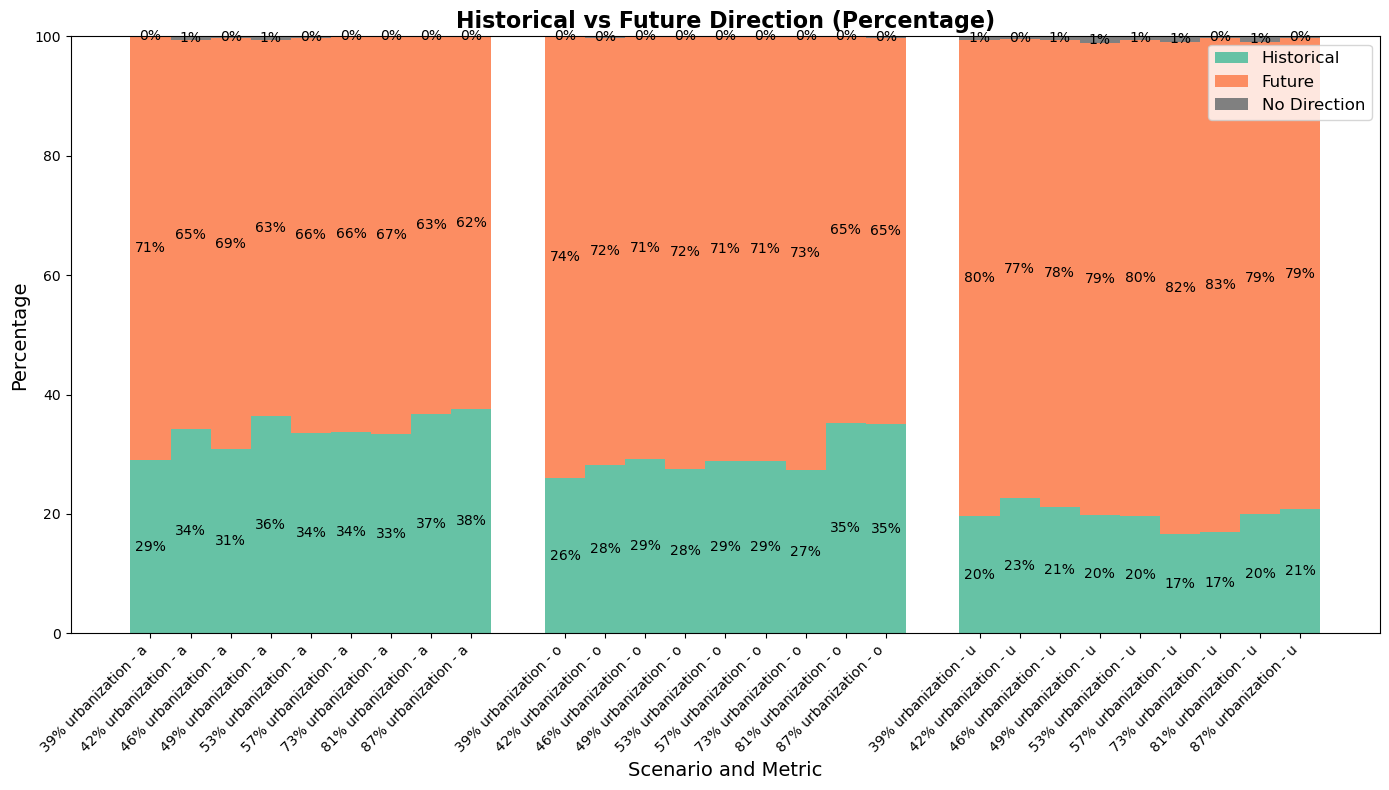

In [4]:
# Initialize the figure
fig, ax = plt.subplots(figsize=(14, 8))  # Slightly wider for better spacing

# Plot the data
width = 0.15
spacing = 0.2  # Adjust spacing between groups
n = len(all_data)
bar_positions = []
bar_labels = []

for i, (all_events_direc_df, label) in enumerate(zip(all_data, labels)):
    # Calculate percentages for each count
    all_events_direc_df['historical_percentage'] = (
        all_events_direc_df['historical_count'] / 
        (all_events_direc_df['historical_count'] + all_events_direc_df['future_count'] + all_events_direc_df['no_direction']) * 100
    )
    all_events_direc_df['future_percentage'] = (
        all_events_direc_df['future_count'] / 
        (all_events_direc_df['historical_count'] + all_events_direc_df['future_count'] + all_events_direc_df['no_direction']) * 100
    )
    all_events_direc_df['no_direction_percentage'] = (
        all_events_direc_df['no_direction'] / 
        (all_events_direc_df['historical_count'] + all_events_direc_df['future_count'] + all_events_direc_df['no_direction']) * 100
    )

    # Adjust positions for each group with additional spacing
    pos = [j * (n * width + spacing) + i * width for j in range(len(all_events_direc_df))]
    bar_positions.extend(pos)
    bar_labels.extend([f'{label} - {metric[1]}' for metric in all_events_direc_df.index])

    # Plot bars for historical and future percentages
    bars1 = ax.bar(pos, all_events_direc_df['historical_percentage'], width=width, color=historical_color)
    bars2 = ax.bar(
        pos,
        all_events_direc_df['future_percentage'],
        bottom=all_events_direc_df['historical_percentage'],
        width=width,
        color=future_color,
    )
    bars3 = ax.bar(
        pos,
        all_events_direc_df['no_direction_percentage'],
        bottom=all_events_direc_df['historical_percentage'] + all_events_direc_df['future_percentage'],
        width=width,
        color='gray',
    )

    # Adding annotations for the percentages
    for bar, hist_pct, fut_pct, no_dir_pct in zip(
        bars1,
        all_events_direc_df['historical_percentage'],
        all_events_direc_df['future_percentage'],
        all_events_direc_df['no_direction_percentage'],
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            hist_pct / 2,
            f'{hist_pct:.0f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='black',
        )
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            hist_pct + fut_pct / 2,
            f'{fut_pct:.0f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='black',
        )
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            hist_pct + fut_pct + no_dir_pct / 2,
            f'{no_dir_pct:.0f}%',
            ha='center',
            va='center',
            fontsize=10,
            color='black',
        )

# Customize the plot
plt.title('Historical vs Future Direction (Percentage)', fontsize=16, fontweight='bold')
plt.xlabel('Scenario and Metric', fontsize=14)
plt.ylabel('Percentage', fontsize=14)

# Set x-ticks positions and labels for each bar
ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=10)

# Create custom legend
hist_patch = plt.Rectangle((0, 0), 1, 1, fc=historical_color, edgecolor='none', label='Historical')
future_patch = plt.Rectangle((0, 0), 1, 1, fc=future_color, edgecolor='none', label='Future')
no_dir_patch = plt.Rectangle((0, 0), 1, 1, fc='gray', edgecolor='none', label='No Direction')
plt.legend(handles=[hist_patch, future_patch, no_dir_patch], fontsize=12)

plt.tight_layout()

# Save the plot
barplot_path = os.path.join(save_dir, 'all_events_direction_percentage_bar_plot_combined.png')
plt.savefig(barplot_path, dpi=300)
plt.show()


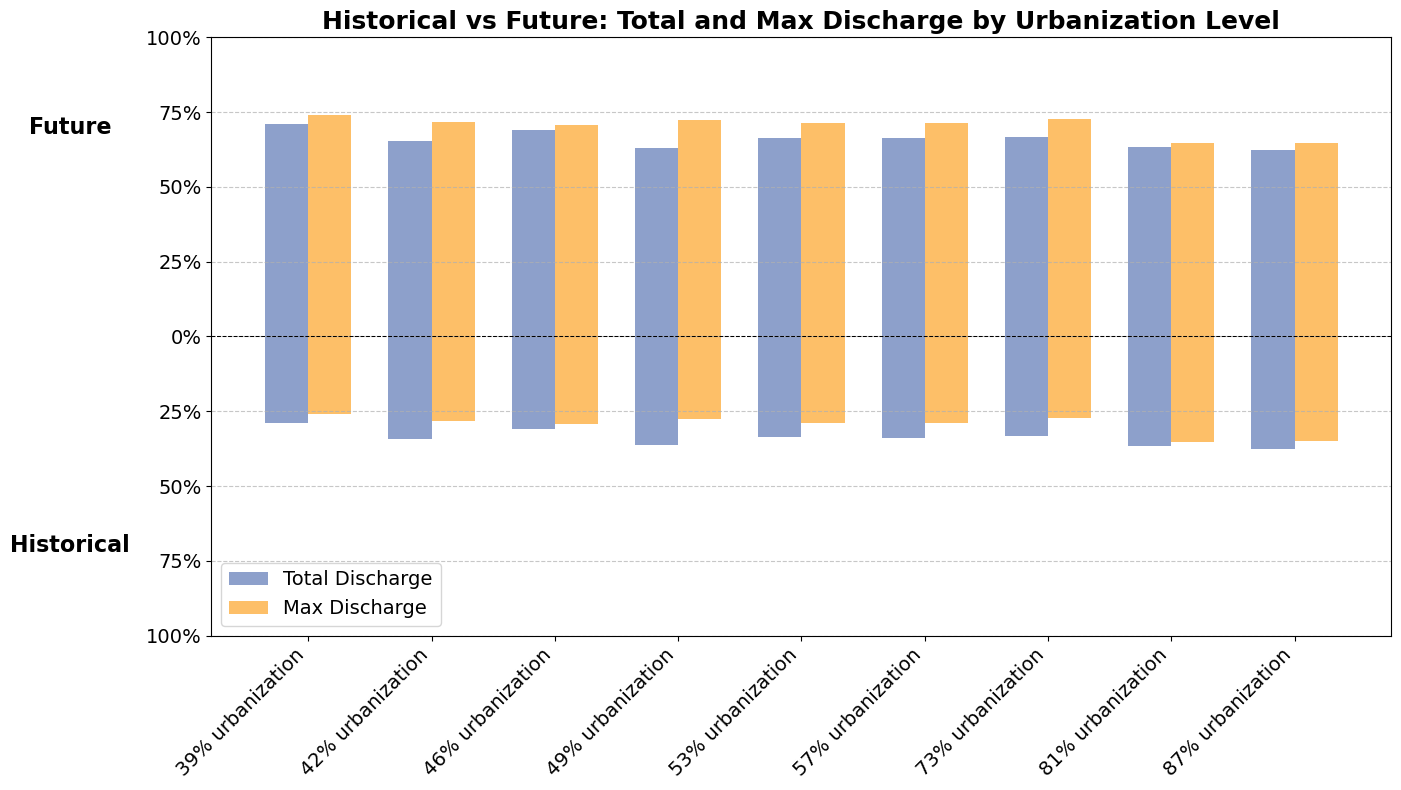

In [5]:
# Define the colors
color_total = '#8DA0CB'  # Blue for total discharge
color_max = '#FDBF68'    # Orange for max discharge

# Define the x-axis positions and labels
x_positions = np.arange(len(labels))
bar_width = 0.35

# Prepare data
historical_total = [df['historical_percentage'].iloc[0] for df in all_data]
future_total = [df['future_percentage'].iloc[0] for df in all_data]
historical_max = [df['historical_percentage'].iloc[1] for df in all_data]
future_max = [df['future_percentage'].iloc[1] for df in all_data]

# Create the figure
fig, ax = plt.subplots(figsize=(14, 8))

# Plot historical total discharge (below x-axis)
ax.bar(x_positions - bar_width / 2, [-val for val in historical_total],
       width=bar_width, color=color_total, label='Total Discharge')

# Plot future total discharge (above x-axis)
ax.bar(x_positions - bar_width / 2, future_total,
       width=bar_width, color=color_total)

# Plot historical max discharge (below x-axis)
ax.bar(x_positions + bar_width / 2, [-val for val in historical_max],
       width=bar_width, color=color_max, label='Max Discharge')

# Plot future max discharge (above x-axis)
ax.bar(x_positions + bar_width / 2, future_max,
       width=bar_width, color=color_max)

# Customize the plot
ax.set_title('Historical vs Future: Total and Max Discharge by Urbanization Level', fontsize=18, fontweight='bold')
# ax.set_ylabel('Percentage (%)', fontsize=16)
# ax.set_xlabel('Urbanization Level', fontsize=16)
ax.set_xticks(x_positions)
ax.set_xticklabels([label for _, _, label in rain_shift_classes], rotation=45, ha='right', fontsize=14)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.75)  # Add horizontal line at 0
ax.set_ylim(-100, 100)

# Adjust Y-axis labels to show positive values for both directions
y_ticks = ax.get_yticks()
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{abs(int(tick))}%' for tick in y_ticks], fontsize=14)

# Add text labels to the left of the Y-axis
ax.text(-0.12, 0.85, 'Future', transform=ax.transAxes, fontsize=16, weight='bold', ha='center', va='center', color='black')
ax.text(-0.12, 0.15, 'Historical', transform=ax.transAxes, fontsize=16, weight='bold', ha='center', va='center', color='black')

# Adjust legend
ax.legend(loc='upper left', fontsize=14, title_fontsize=16)

# Add gridlines
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Save the figure
plt.tight_layout()
combined_plot_path = os.path.join(save_dir, 'combined_discharge_direction_single_plot_with_labels.png')
plt.savefig(combined_plot_path, dpi=300)
plt.show()
